In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


c:\Users\yamen\Desktop\Weiterbildung\visual Studio Code\mein-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "miadul/dna-classification-dataset" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

100%|██████████| 140k/140k [00:00<00:00, 603kB/s]

Extracting files...
Loading dataset from C:\Users\yamen\.cache\kagglehub\datasets\miadul\dna-classification-dataset\versions\1 to ../data/raw\dna-classification-dataset
Moving file: C:\Users\yamen\.cache\kagglehub\datasets\miadul\dna-classification-dataset\versions\1\synthetic_dna_dataset.csv to c:\Users\yamen\Desktop\Weiterbildung\visual Studio Code\mein-project\notebooks\../data/raw\dna-classification-dataset
Files moved to '../data/raw\dna-classification-dataset' directory.


In [3]:
files

['synthetic_dna_dataset.csv']

In [4]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df.head()

,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk
0,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,50.0,50.0,100,22,28,19,31,0.986,0,Bacteria,High
1,SAMPLE_2,TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...,45.0,55.0,100,27,28,22,23,0.486,1,Virus,Medium
2,SAMPLE_3,GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...,51.0,49.0,100,26,23,30,21,0.367,1,Bacteria,Low
3,SAMPLE_4,ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...,55.0,45.0,100,28,17,23,32,0.404,0,Human,Medium
4,SAMPLE_5,TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...,46.0,54.0,100,24,30,25,21,0.818,0,Human,High


In [5]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(3000, 13)

'Description'

,count,mean,std,min,25%,50%,75%,max
GC_Content,3000.0,50.12,5.06,34.0,47.00,50.00,53.00,66.0
AT_Content,3000.0,49.88,5.06,34.0,47.00,50.00,53.00,66.0
Sequence_Length,3000.0,100.00,0.00,100.0,100.00,100.00,100.00,100.0
Num_A,3000.0,24.95,4.32,11.0,22.00,25.00,28.00,40.0
Num_T,3000.0,24.93,4.32,9.0,22.00,25.00,28.00,42.0
Num_C,3000.0,25.00,4.35,10.0,22.00,25.00,28.00,42.0
Num_G,3000.0,25.12,4.33,12.0,22.00,25.00,28.00,42.0
kmer_3_freq,3000.0,0.55,0.26,0.1,0.33,0.54,0.77,1.0
Mutation_Flag,3000.0,0.50,0.50,0.0,0.00,0.00,1.00,1.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
Sample_ID,object,0,3000,"[SAMPLE_2711, SAMPLE_1815, SAMPLE_2062]"
Sequence,object,0,3000,[ACTGCCGGACTAAGATGCAGTTAACGCTCCGGTGTCCACAACACT...
GC_Content,float64,0,33,"[43.0, 57.0, 49.0]"
AT_Content,float64,0,33,"[53.0, 50.0, 51.0]"
Sequence_Length,int64,0,1,"[100, 100, 100]"
Num_A,int64,0,30,"[30, 17, 25]"
Num_T,int64,0,32,"[20, 25, 28]"
Num_C,int64,0,32,"[21, 28, 19]"
Num_G,int64,0,30,"[23, 27, 26]"
kmer_3_freq,float64,0,872,"[0.138, 0.926, 0.7]"


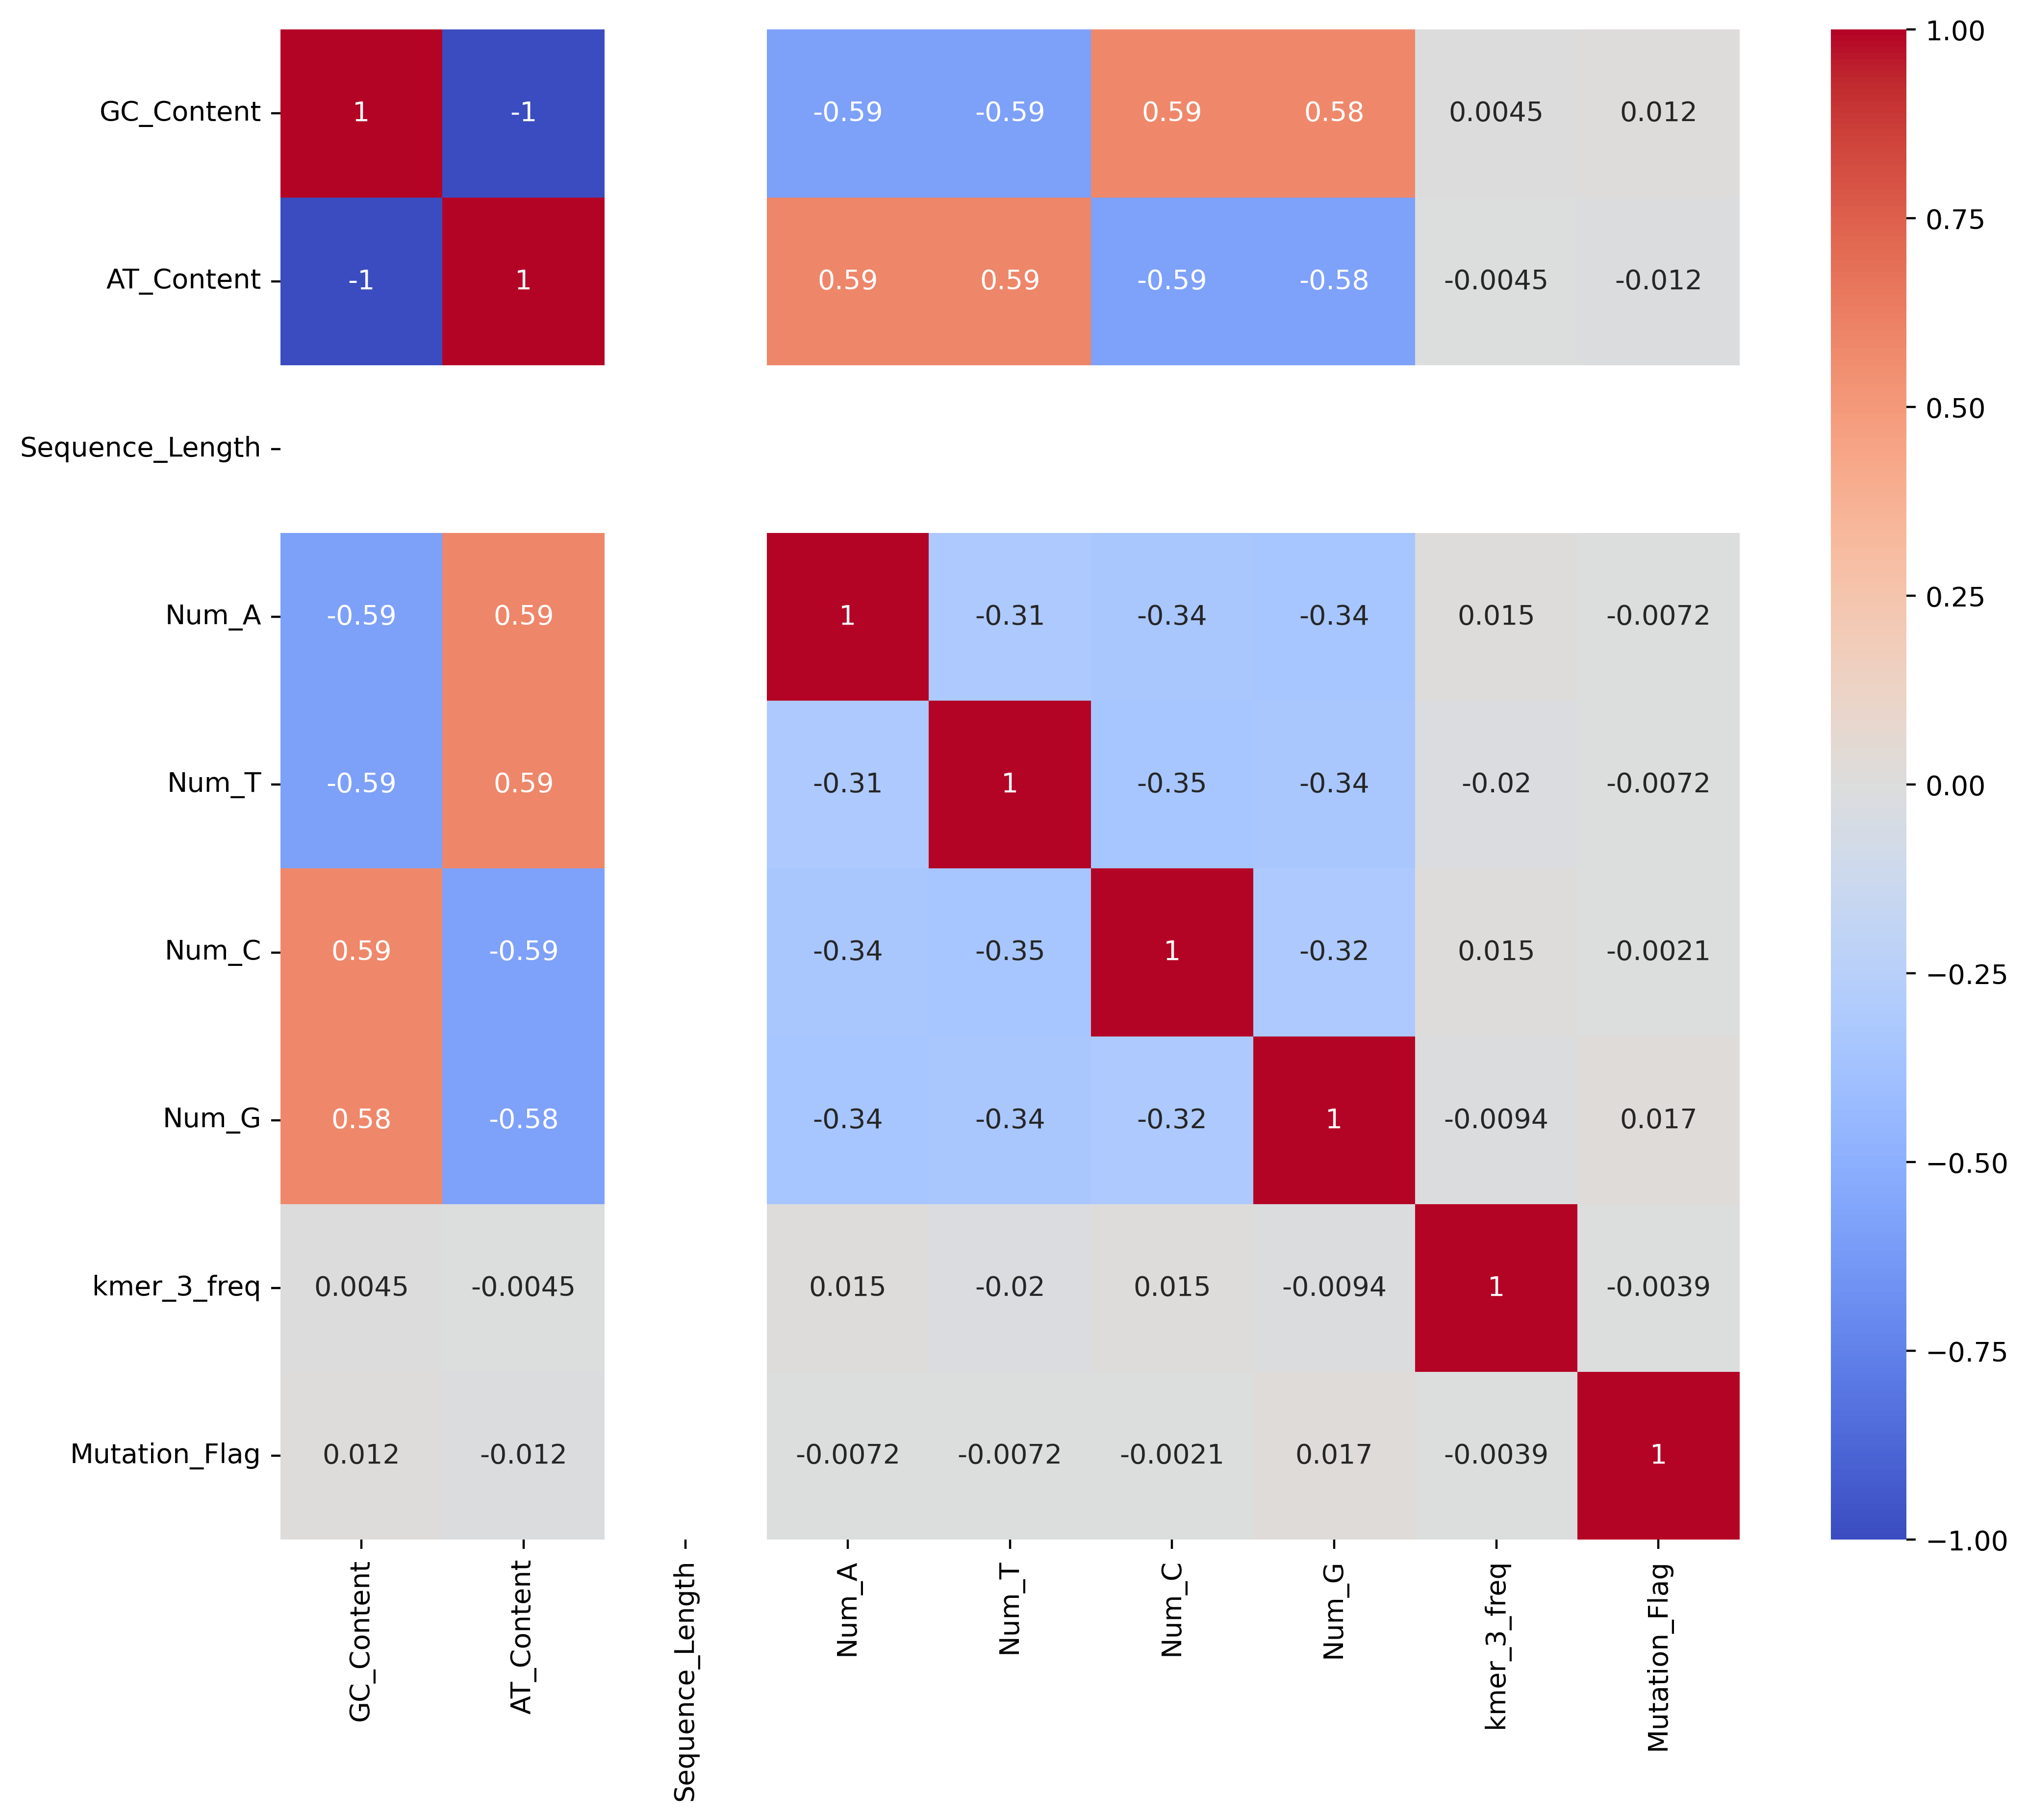

In [6]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=400)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);